# Experiment Guide: Zero-Shot OBB Vehicle Detection & Ego-Motion Compensation for LaMa

This document outlines the step-by-step Jupyter Notebook structure to run the **Fase 0: Pseudo-Labeling Temporal** experiment in Google Colab.

To avoid the model learning to suppress parked vehicles (which occurs if trained on the original MTC dataset because parked vehicles are not annotated in `train.csv` and are treated as background), we perform **Zero-Shot inference** using factory weights trained on the massive aerial dataset **DOTA v1.0**.

---

## 1. Environment & Hardware Settings in Google Colab

### 1.1 Hardware Accelerator Selection
* **Option Choice**: Google Colab Free Tier offers a **T4 GPU** and a **TPU v5e**. For YOLO models, you **MUST select the T4 GPU**.
* **Reasoning**: YOLO26 and PyTorch are optimized natively for CUDA on GPUs. Running OBB detection on TPUs requires converting models to ONNX and compiling them via specialized TPU toolchains, which is complex, prone to operator mismatches, and slower for iterative research.
* **Path to configure**: In Colab, go to `Runtime` -> `Change runtime type` -> select `T4 GPU` from Hardware accelerator dropdown.

### 1.2 Output Directory Location
* **JSON Target Location**: We save the resulting coordinate map to `/content/drive/MyDrive/ia_article/01_processed/static_vehicles.json`.
* **Reasoning**: Storing it in `01_processed/` keeps all parsed, cleaned, and processed metadata files (alongside `split_metadata.csv` and `smart_dataset.yaml`) grouped together, avoiding root-level directory clutter.

---

## 2. Scientific Validation from Literature

### 2.1 Model Scale: YOLO26s-OBB vs. Larger Variants
* **Recall Optimization**: Since this is an offline pre-processing stage to generate masks for LaMa, inference speed is not a constraint. Our primary objective is to maximize the **recall** of parked vehicles to avoid leaving unlabeled cars in the background.
* **Literature Alignment**: According to Wang et al., 2023 (`Wang2023`) and Li et al., 2023 (`Li2023`), larger backbones like `yolo26m-obb` (21.2M parameters) or `yolo26l-obb` (25.6M parameters) capture finer spatial details and have a significantly higher recall for small, dense, and partially occluded objects (common in aerial drone views) compared to `yolo26s-obb` (9.8M parameters).
* **Recommendation**: While we use `yolo26s-obb` for initial testing to save download time, we recommend upgrading to `yolo26m-obb` or `yolo26l-obb` for the final production run, as Google Colab T4 GPUs have sufficient VRAM to handle them without out-of-memory (OOM) errors during single-frame inference.

### 2.2 Motion Compensation: Homography Matrix Validation
* **UAV Ego-Motion**: High-altitude drone cameras experience constant camera movement (translations, rotations, drift). Compensating for this movement is essential to prevent camera motion from being misclassified as vehicle motion.
* **Literature Precedent**: Aligning sequential frames by estimating a 3x3 homography matrix ($H$) via feature matching (ORB/SIFT) and RANSAC is a well-established, mathematically rigorous method used by authors for aerial object tracking (Xiao et al., 2025 `Xiao2025`; Fernandez-Rodriguez et al., 2023 `FernandezRodriguez2023`; Chen et al., 2025 `Chen2025`).
* **Alternative Methods**:
  * **SuperPoint + LightGlue**: SIFT or SuperPoint features are more robust to illumination changes and perspective distortion than ORB, and LightGlue filters matches more effectively than brute-force Hamming distance. It is slower but provides higher alignment accuracy.
  * **Dense Optical Flow (e.g., Farneback)**: Calculates dense pixel-level motion vectors. While robust to local surface changes, it is computationally expensive and struggles in large, homogeneous regions like clean asphalt.
* **Conclusion**: ORB + RANSAC homography is chosen for this prototype as it offers a fast, robust, and native CPU-supported baseline.

### 2.3 Dataset Cleaning Policy
The objective of this phase is to remove unlabeled parked cars. We apply the following rules:
1. **Annotated in Ground Truth (`train.csv`)** $\to$ **CONSERVE** (Keep). Even if the vehicle is temporarily static (e.g., waiting at a traffic light), it has an annotation. The model will not be penalized for detecting it, so we must not remove it.
2. **Detected by YOLO but Static & Unannotated** $\to$ **CLEAN** (Inpaint with LaMa). These are the parked vehicles that introduce label noise. We remove them and reconstruct the asphalt underneath.
3. **Not Detected by YOLO & Unannotated** $\to$ **UNALTERED** (Missed). If YOLO fails to detect a parked car, we cannot mask it. This highlights the importance of maximizing YOLO's recall.

---


In [2]:
!pip install -q ultralytics

import os
import cv2
import json
import math
import numpy as np
import pandas as pd
from PIL import Image
import zipfile
import io
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Setup paths based on the Drive structure
DRIVE_DIR = "/content/drive/MyDrive/ia_article"
CSV_PATH = os.path.join(DRIVE_DIR, "00_raw/train.csv")
IMAGES_ZIP_PATH = os.path.join(DRIVE_DIR, "00_raw/train.zip")
OUTPUT_JSON_PATH = os.path.join(DRIVE_DIR, "02_pseudo_labeling/static_vehicles.json")

# Define a small clip sample for testing (2 clips instead of 1,088)
TEST_CLIPS = ['v_009evckk5b', 'v_016is7moli', 'v_01tp2eyell', 'v_03ah598sio','v_09gpsv2mc8']

print("Environment initialized. Ready to test with clips:", TEST_CLIPS)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.9 MB/s eta 0:00:00
Mounted at /content/drive
Environment initialized. Ready to test with clips: ['v_009evckk5b', 'v_016is7moli', 'v_01tp2eyell', 'v_03ah598sio', 'v_09gpsv2mc8']


Load the pre-trained `yolo26s-obb.pt` weights. We dynamically find the indices corresponding to vehicles by checking the class names instead of hardcoding them, avoiding class index shifts between YOLO DOTA variants.


In [3]:
from ultralytics import YOLO

# Load the DOTA pre-trained YOLO26s-OBB model
# For maximum recall on production, you can replace this with "yolo26m-obb.pt" or "yolo26l-obb.pt"
model = YOLO("yolo26m-obb.pt")

print("=== Class Map Verification ===")
print("Model names map:")
print(*model.names.values(), sep='\n')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== Class Map Verification ===
Model names map:
plane
ship
storage tank
baseball diamond
tennis court
basketball court
ground track field
harbor
bridge
large vehicle
small vehicle
helicopter
roundabout
soccer ball field
swimming pool


In [4]:
# Dynamic mapping of vehicle indices (handles spaces, hyphens, and casing differences)
VEHICLE_CLASS_IDS = []
for idx, name in model.names.items():
    clean_name = name.lower().replace('-', ' ').replace('_', ' ')
    if any(keyword in clean_name for keyword in ['small vehicle', 'large vehicle', 'car', 'bus', 'truck', 'vehicle']):
        VEHICLE_CLASS_IDS.append(int(idx))

print(f"Dynamically resolved vehicle class IDs: {VEHICLE_CLASS_IDS}")
assert len(VEHICLE_CLASS_IDS) > 0, "Error: No vehicle classes found in model.names mapping!"


Dynamically resolved vehicle class IDs: [9, 10]


## Homography (Ego-Motion Compensation) Module
Implement an ORB-based keypoint tracker with RANSAC robust matching. To prevent the movement of vehicles from warping the estimated camera homography, we mask out the pixels inside current YOLO detections.


In [5]:
def estimate_homography(prev_gray, curr_gray, prev_detections=None):
    """
    Computes the 3x3 homography matrix between prev and curr frames,
    excluding keypoints detected inside foreground vehicle boxes.
    """
    # Initialize ORB detector
    orb = cv2.ORB_create(nfeatures=2500)

    # Build a background mask (0: vehicle/foreground, 255: background)
    bg_mask = np.ones_like(prev_gray, dtype=np.uint8) * 255
    if prev_detections is not None:
        # Loop through detected vehicle polygons/bounding boxes
        for det in prev_detections:
            # det expected in poly format: [x1, y1, x2, y2, x3, y3, x4, y4]
            poly = np.array(det, dtype=np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(bg_mask, [poly], 0)

    # Find the keypoints and descriptors with ORB
    kp1, des1 = orb.detectAndCompute(prev_gray, mask=bg_mask)
    kp2, des2 = orb.detectAndCompute(curr_gray, mask=None)

    if des1 is None or des2 is None or len(kp1) < 15 or len(kp2) < 15:
        # Return Identity matrix and flag failure
        return np.eye(3), False

    # Match descriptors using Hamming distance
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    if len(matches) < 10:
        return np.eye(3), False

    # Extract coordinate points
    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    # Calculate Homography matrix
    H, status = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if H is None or np.sum(status) < 10:
        return np.eye(3), False

    return H, True

def project_centroid(cx, cy, H):
    """
    Project coordinate (cx, cy) using the homography matrix H.
    """
    pt = np.array([cx, cy, 1.0]).reshape(3, 1)
    projected = np.dot(H, pt)
    w = projected[2, 0]
    if abs(w) > 1e-6:
        return projected[0, 0] / w, projected[1, 0] / w
    return cx, cy


# Multi-Frame Tracking and Association
Track OBB centroids across the frames of a clip (~50 frames) using a greedy distance threshold after applying the inter-frame homography projection.


In [6]:
class CentroidTracker:
    def __init__(self, max_distance=30.0):
        self.next_object_id = 0
        self.objects = {}      # ID -> last_centroid
        self.history = {}      # ID -> list of (frame_idx, cx, cy, w, h, angle, conf)
        self.max_distance = max_distance

    def update(self, frame_idx, detections, H):
        """
        Updates trackers. Detections list format: [(cx, cy, w, h, angle, conf), ...]
        H: Homography matrix mapping previous frame coordinates to the current frame.
        """
        # 1. Project existing trackers into the current frame coordinate system using H
        projected_objects = {}
        for obj_id, centroid in self.objects.items():
            pcx, pcy = project_centroid(centroid[0], centroid[1], H)
            projected_objects[obj_id] = (pcx, pcy)

        # 2. Match projected objects with new detections
        new_objects = {}
        assigned_det_indices = set()

        if len(projected_objects) > 0 and len(detections) > 0:
            object_ids = list(projected_objects.keys())
            object_points = np.array(list(projected_objects.values()))
            det_points = np.array([ [d[0], d[1]] for d in detections ])

            # Greedy association
            for i, obj_id in enumerate(object_ids):
                # Calculate Euclidean distance to all current detections
                dists = np.linalg.norm(det_points - object_points[i], axis=1)
                min_idx = np.argmin(dists)

                if dists[min_idx] < self.max_distance and min_idx not in assigned_det_indices:
                    # Match found
                    det = detections[min_idx]
                    new_objects[obj_id] = (det[0], det[1]) # Update last centroid
                    self.history[obj_id].append((frame_idx, *det))
                    assigned_det_indices.add(min_idx)

        # 3. Handle unassigned current detections (initialize new tracks)
        for idx, det in enumerate(detections):
            if idx not in assigned_det_indices:
                new_id = self.next_object_id
                self.next_object_id += 1
                new_objects[new_id] = (det[0], det[1])
                self.history[new_id] = [(frame_idx, *det)]

        # Update active trackers
        self.objects = new_objects


## Static Classifier and Ground Truth Exclusion
Cross-reference tracked trajectories against the Ground Truth (MTC annotations for moving vehicles). If a trajectory does NOT match the moving vehicles, has lasted at least 10 frames, and displays negligible residual displacement, it is classified as a parked vehicle.


In [12]:
def check_gt_matching(tracked_cx, tracked_cy, gt_df, frame_idx, dist_threshold=30.0):
    """
    Check if a tracked centroid matches any annotated moving vehicle in the ground truth.
    """
    frame_gt = gt_df[gt_df['frame_idx'] == frame_idx]
    if frame_gt.empty:
        return False

    # Standard Euclidean distance match (could be upgraded to oriented IoU later)
    gt_coords = frame_gt[['cx', 'cy']].values
    dists = np.linalg.norm(gt_coords - np.array([tracked_cx, tracked_cy]), axis=1)

    return np.any(dists < dist_threshold)

def filter_static_vehicles(tracker_history, gt_df, min_frames=10, motion_threshold=8.0):
    """
    Filters tracked trajectories to isolate static vehicles that do not match the GT.
    """
    static_detections = {} # frame_name -> list of boxes

    for obj_id, traj in tracker_history.items():
        if len(traj) < min_frames:
            continue

        # Calculate maximum spatial dispersion across the trajectory (drift)
        coords = np.array([ [pt[1], pt[2]] for pt in traj ])
        dx = np.max(coords[:, 0]) - np.min(coords[:, 0])
        dy = np.max(coords[:, 1]) - np.min(coords[:, 1])
        drift = math.sqrt(dx**2 + dy**2)

        # Check if the trajectory is static
        if drift < motion_threshold:
            # Check overlap with Ground Truth moving vehicles
            has_gt_match = False
            for step in traj:
                frame_idx, cx, cy = step[0], step[1], step[2]
                if check_gt_matching(cx, cy, gt_df, frame_idx):
                    has_gt_match = True
                    break

            # If it's static and NOT already in the Ground Truth, save it!
            if not has_gt_match:
                for step in traj:
                    frame_idx, cx, cy, w, h, angle, conf = step
                    frame_name = f"frame_{frame_idx:04d}" # Standard frame format

                    if frame_name not in static_detections:
                        static_detections[frame_name] = []

                    static_detections[frame_name].append({
                        "cx": float(cx),
                        "cy": float(cy),
                        "w": float(w),
                        "h": float(h),
                        "angle": float(angle),
                        "conf": float(conf)
                    })

    return static_detections


## Run Pipeline on a Sample of Clips
This cell contains crucial technical corrections to prevent desync, class index mismatch, and angle unit errors. We print logs to allow verifying data at runtime.


In [25]:
def process_sample_dataset(csv_path, zip_path, test_clips, output_json_path):
    print("Loading annotations database...")
    df_raw = pd.read_csv(csv_path)

    # Parse coordinates for GT matching
    # Filter rows belonging to our test clips
    df_raw['clip_id'] = df_raw['Id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    df_raw_sub = df_raw[df_raw['clip_id'].isin(test_clips)].copy()

    # Parse annotations into detailed DataFrame
    parsed_records = []
    for _, row in df_raw_sub.iterrows():
        frame_id = row['Id']
        target = row['Target']
        parts = frame_id.split('_')
        clip_id = '_'.join(parts[:-1])
        frame_idx = int(parts[-1])

        if target == 'none' or pd.isna(target):
            continue
        for ann in target.split(';'):
            parts_ann = ann.strip().split(' ')
            if len(parts_ann) == 6:
                parsed_records.append({
                    'Id': frame_id, 'clip_id': clip_id, 'frame_idx': frame_idx,
                    'cx': float(parts_ann[1]), 'cy': float(parts_ann[2])
                })
    gt_df = pd.DataFrame(parsed_records) if parsed_records else pd.DataFrame(columns=['Id', 'clip_id', 'frame_idx', 'cx', 'cy'])

    all_static_data = {}

    with zipfile.ZipFile(zip_path, 'r') as z:
        zip_files = z.namelist()

        for clip in test_clips:
            print(f"\n--- Processing Clip: {clip} ---")
            # Get and sort all frames belonging to this clip in the zip file
            clip_frames = sorted([f for f in zip_files if clip in f and f.endswith(('.jpg', '.png'))])

            if not clip_frames:
                print(f"Warning: No frames found in ZIP for clip {clip}")
                continue

            tracker = CentroidTracker()
            prev_gray = None
            prev_dets_poly = None

            # Diagnostic counters
            total_detections_count = 0
            homography_failures = 0

            for index_in_loop, frame_zip_path in enumerate(tqdm(clip_frames)):
                # --- BUG CORRECTION #2: Prevent index desync if a frame is missing ---
                # We extract the actual frame_idx from the file name instead of using loop index
                frame_id_str = os.path.basename(frame_zip_path).split('.')[0]
                frame_idx = int(frame_id_str.split('_')[-1])

                # Read bytes and decode
                with z.open(frame_zip_path) as file:
                    img_bytes = file.read()
                nparr = np.frombuffer(img_bytes, np.uint8)
                img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # 1. Homography calculation
                if index_in_loop > 0:
                    H, success = estimate_homography(prev_gray, gray, prev_dets_poly)
                    if not success:
                        homography_failures += 1
                else:
                    H = np.eye(3)

                # 2. YOLO OBB Inference
                # We use conf=0.40 to reduce false positives
                results = model.predict(img, conf=0.25, verbose=False)l
                detections = []
                current_polys = []

                for r in results:
                    if r.obb is not None:
                        for box in r.obb:
                            cls_id = int(box.cls[0].item())
                            # --- BUG CORRECTION #3: Dynamic class indexing ---
                            # Filter using resolved vehicle IDs from Cell 2
                            if cls_id in VEHICLE_CLASS_IDS:
                                xywhr = box.xywhr[0].cpu().numpy()
                                conf = float(box.conf[0].item())
                                cx, cy, w, h, angle = xywhr

                                # --- BUG CORRECTION #1: Convert OBB angle from Radians to Degrees ---
                                angle_deg = math.degrees(angle)

                                detections.append((cx, cy, w, h, angle_deg, conf))

                                xyxyxyxy = box.xyxyxyxy[0].cpu().numpy()
                                current_polys.append(xyxyxyxy)

                                total_detections_count += 1

                # 3. Update Tracker with true frame index
                tracker.update(frame_idx, detections, H)

                prev_gray = gray
                prev_dets_poly = current_polys

            # Log clip diagnostics
            print(f"[{clip}] Processing Summary:")
            print(f"  Processed Frames: {len(clip_frames)}")
            print(f"  Total Raw OBB Detections: {total_detections_count}")
            print(f"  Homography Failures: {homography_failures} (should be 0 or very close to 0)")
            print(f"  Active Tracks generated: {tracker.next_object_id}")

            # Filter static objects for this clip
            clip_gt_df = gt_df[gt_df['clip_id'] == clip]
            clip_static_map = filter_static_vehicles(tracker.history, clip_gt_df)

            # Save into global map using standard frame ID keys
            for local_frame_name, boxes in clip_static_map.items():
                frame_id = f"{clip}_{local_frame_name.split('_')[-1]}"
                all_static_data[frame_id] = boxes

    # Save output to Drive
    os.makedirs(os.path.dirname(output_json_path), exist_ok=True)
    with open(output_json_path, 'w') as f:
        json.dump(all_static_data, f, indent=2)

    print(f"\n✓ Test completed. Output coordinate file saved to: {output_json_path}")
    print(f"Total frames containing static vehicles: {len(all_static_data)}")

    # Print a tiny slice of the JSON output for validation
    sample_key = list(all_static_data.keys())[0] if all_static_data else None
    if sample_key:
        print("\n=== Sample JSON Data Output ===")
        print(f"Key '{sample_key}':", json.dumps(all_static_data[sample_key][:2], indent=2))

    return all_static_data, gt_df

# Run test execution
static_data, gt_df = process_sample_dataset(CSV_PATH, IMAGES_ZIP_PATH, TEST_CLIPS, OUTPUT_JSON_PATH)


Loading annotations database...

--- Processing Clip: v_009evckk5b ---


  0%|          | 0/50 [00:00<?, ?it/s]

[v_009evckk5b] Processing Summary:
  Processed Frames: 50
  Total Raw OBB Detections: 1222
  Homography Failures: 0 (should be 0 or very close to 0)
  Active Tracks generated: 67

--- Processing Clip: v_016is7moli ---


  0%|          | 0/50 [00:00<?, ?it/s]

[v_016is7moli] Processing Summary:
  Processed Frames: 50
  Total Raw OBB Detections: 854
  Homography Failures: 0 (should be 0 or very close to 0)
  Active Tracks generated: 41

--- Processing Clip: v_01tp2eyell ---


...

[v_01tp2eyell] Processing Summary:
  Processed Frames: 50
  Total Raw OBB Detections: 729
  Homography Failures: 0 (should be 0 or very close to 0)
  Active Tracks generated: 21

--- Processing Clip: v_03ah598sio ---


  0%|          | 0/50 [00:00<?, ?it/s]

[v_03ah598sio] Processing Summary:
  Processed Frames: 50
  Total Raw OBB Detections: 785
  Homography Failures: 0 (should be 0 or very close to 0)
  Active Tracks generated: 25

--- Processing Clip: v_09gpsv2mc8 ---


  0%|          | 0/50 [00:00<?, ?it/s]

[v_09gpsv2mc8] Processing Summary:
  Processed Frames: 50
  Total Raw OBB Detections: 2077
  Homography Failures: 0 (should be 0 or very close to 0)
  Active Tracks generated: 250

✓ Test completed. Output coordinate file saved to: /content/drive/MyDrive/ia_article/02_pseudo_labeling/static_vehicles.json
Total frames containing static vehicles: 250

=== Sample JSON Data Output ===
Key 'v_009evckk5b_0000': [
  {
    "cx": 1047.47314453125,
    "cy": 850.2559204101562,
    "w": 74.83950805664062,
    "h": 30.603805541992188,
    "angle": -0.5786858564386262,
    "conf": 0.8955341577529907
  },
  {
    "cx": 329.7522277832031,
    "cy": 1067.0413818359375,
    "w": 82.52729797363281,
    "h": 26.6047306060791,
    "angle": -0.9322574290135063,
    "conf": 0.8904126882553101
  }
]


## Manual Audit Visualization (Multi-Frame Sequence Verification)
To ensure no false positives escape and that static vehicles are correctly aligned, this utility draws multiple frames sequentially (or at specified step intervals) for a selected clip.
Green circles indicate annotated moving vehicles (Ground Truth), and Red circles indicate detected static vehicles to be inpainted by LaMa.


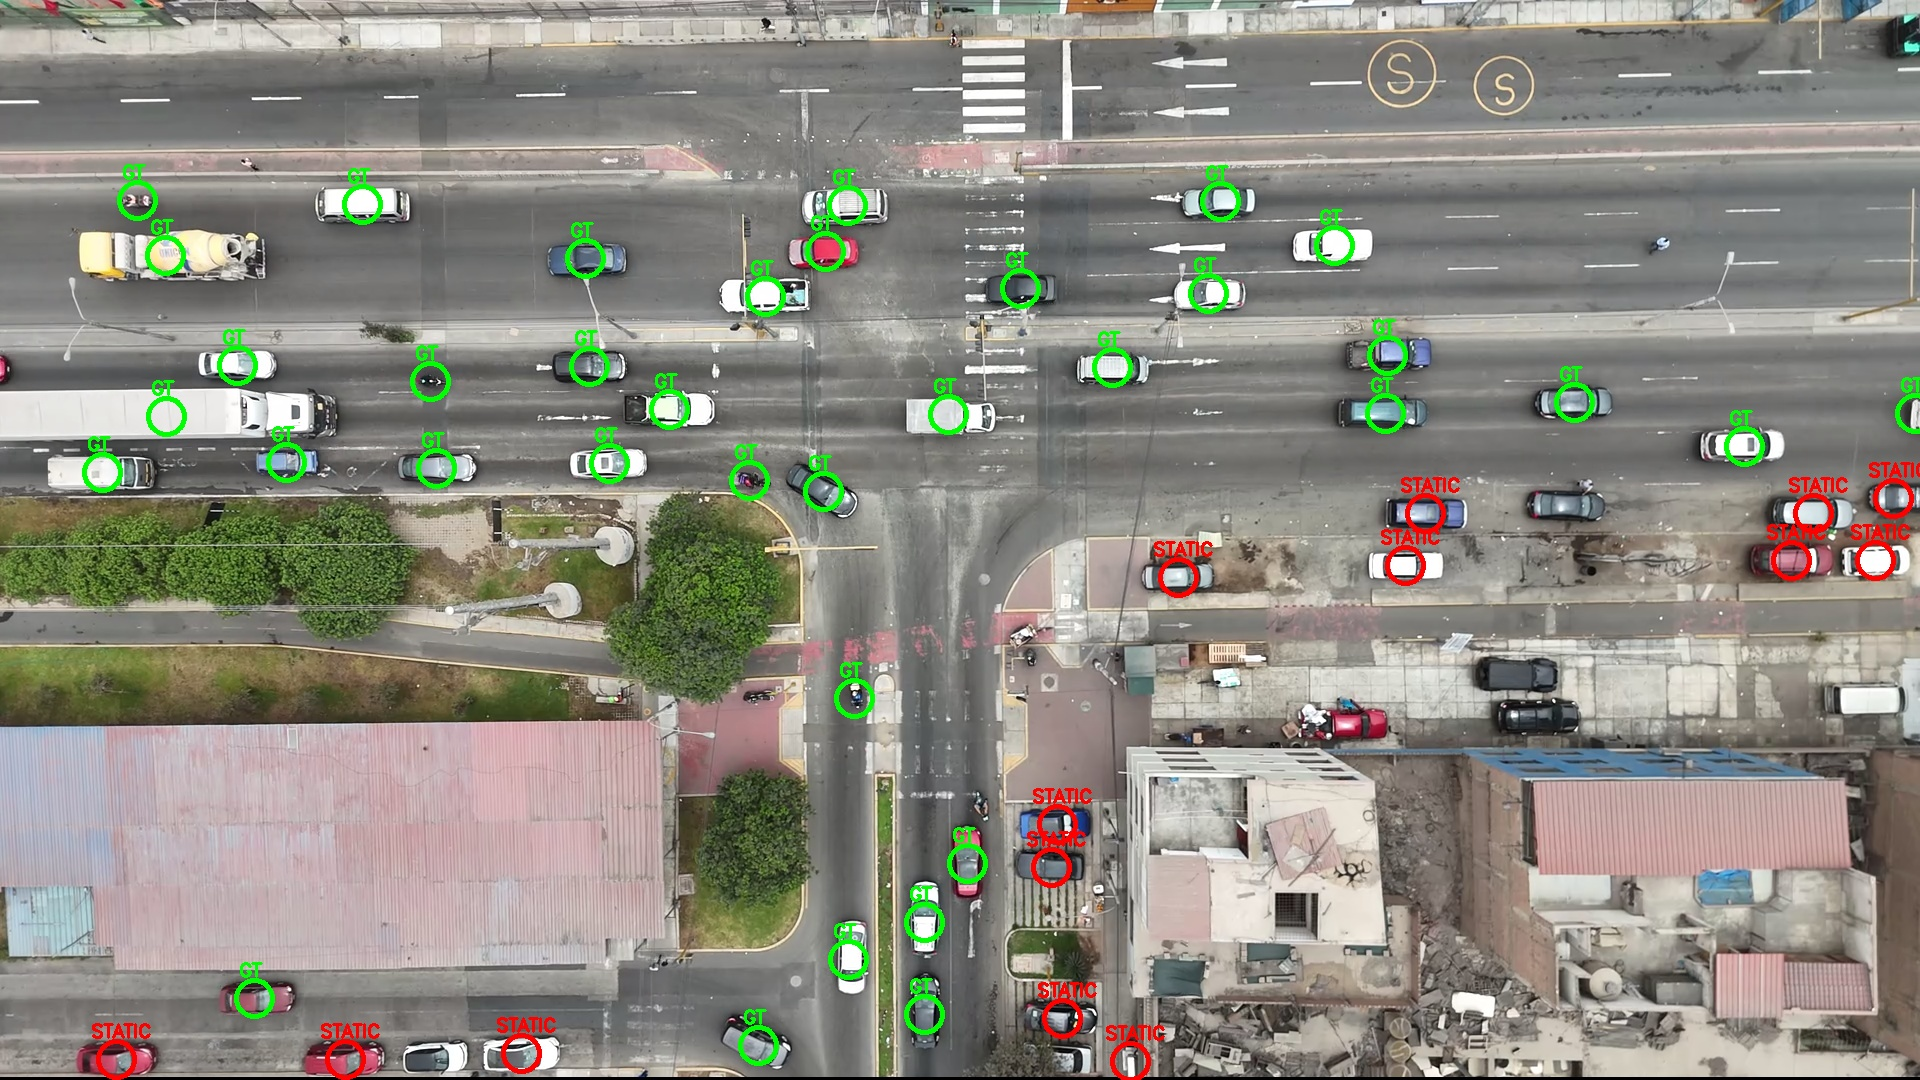

Frame: v_09gpsv2mc8_0014 | Reproduciendo a 3 FPS


KeyboardInterrupt: 

In [26]:
import time
from IPython.display import display, Image as IPyImage, clear_output

def visualize_audit_video(zip_path, clip_id, static_data, gt_df, fps=1):
    """
    Reproduce los fotogramas secuencialmente en la celda para auditoría manual.
    Carga una sola imagen en memoria por iteración.
    """
    print(f"=== Visual Audit Video for Clip: {clip_id} ===")

    # Filtrar coordenadas GT para este clip
    clip_gt = gt_df[gt_df['clip_id'] == clip_id]

    # Calcular el tiempo de espera entre fotogramas
    delay = 1.0 / fps

    with zipfile.ZipFile(zip_path, 'r') as z:
        zip_files = z.namelist()
        clip_frames = sorted([f for f in zip_files if clip_id in f and f.endswith(('.jpg', '.png'))])

        for frame_zip_path in clip_frames:
            frame_id = os.path.basename(frame_zip_path).split('.')[0]
            frame_idx = int(frame_id.split('_')[-1])

            # 1. Lectura eficiente: decodificar directo a array sin mantener el archivo abierto
            with z.open(frame_zip_path) as file:
                img_bytes = file.read()
            nparr = np.frombuffer(img_bytes, np.uint8)
            img = cv2.imdecode(nparr, cv2.IMREAD_COLOR) # Mantiene formato BGR nativo de OpenCV

            # 2. Dibujar Ground Truth (Vehículos en movimiento) en VERDE
            frame_gt = clip_gt[clip_gt['frame_idx'] == frame_idx]
            for _, row in frame_gt.iterrows():
                cv2.circle(img, (int(row['cx']), int(row['cy'])), 18, (0, 255, 0), 3)
                cv2.putText(img, "GT", (int(row['cx']) - 15, int(row['cy']) - 22),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            # 3. Dibujar Vehículos Estáticos (Detectados por YOLO) en ROJO
            frame_static = static_data.get(frame_id, [])
            for static_car in frame_static:
                cx, cy = int(static_car['cx']), int(static_car['cy'])
                # Nota: OpenCV usa BGR, por lo que el rojo puro es (0, 0, 255)
                cv2.circle(img, (cx, cy), 18, (0, 0, 255), 3)
                cv2.putText(img, "STATIC", (cx - 25, cy - 22),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

            # 4. Convertir imagen a formato renderizable por Jupyter
            _, buffer = cv2.imencode('.jpg', img)
            display_img = IPyImage(data=buffer.tobytes())

            # 5. Renderizado dinámico: borrar salida anterior y mostrar la nueva
            clear_output(wait=True)
            display(display_img)
            print(f"Frame: {frame_id} | Reproduciendo a {fps} FPS")

            # Pausa para controlar la velocidad
            time.sleep(delay)

# Ejecuta la visualización para el primer clip. Ajusta el parámetro fps a tu gusto.

visualize_audit_video(IMAGES_ZIP_PATH, TEST_CLIPS[4], static_data, gt_df, fps=3)

In [24]:
# Ruta de tu cuaderno actual en Drive (ajústala si tiene otro nombre)
CUADERNO_PATH = "/content/drive/MyDrive/Colab Notebooks/pseudo_labeling.ipynb"
# Directorio de tu proyecto donde quieres guardar el Markdown y sus imágenes
DESTINO_DIR = "/content/drive/MyDrive/ia_article/temp"

# Ejecutamos la conversión redirigiendo la salida
!jupyter nbconvert --to markdown "$CUADERNO_PATH" --output-dir="$DESTINO_DIR"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/pseudo_labeling.ipynb to markdown
[NbConvertApp] Support files will be in pseudo_labeling_files/
[NbConvertApp] Making directory /content/drive/MyDrive/ia_article/temp/pseudo_labeling_files
[NbConvertApp] Writing 28735 bytes to /content/drive/MyDrive/ia_article/temp/pseudo_labeling.md
